Dataset Preview:
   Customer_ID  Age         Job Marital_Status  Education  Balance  \
0            1   56  management        married  secondary    11975   
1            2   46  technician        married   tertiary    12023   
2            3   32     student        married    primary    22447   
3            4   25       admin         single    primary    25933   
4            5   38     student        married    primary    24959   

  Housing_Loan Personal_Loan  Previous_Contacts  Campaign_Calls Purchased  
0           no           yes                  6               3       yes  
1          yes           yes                  1               3       yes  
2           no           yes                  1               4        no  
3           no            no                  0              11        no  
4          yes            no                  2               1       yes  

Accuracy Score:
0.45

Classification Report:
              precision    recall  f1-score   support

     

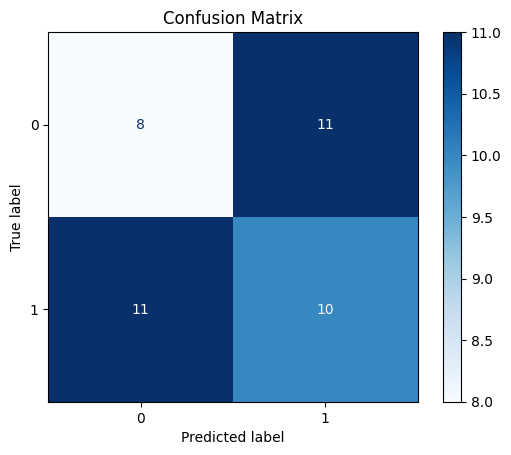

In [3]:
# Decision Tree Classifier for Customer Purchase Prediction

# Import Required Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# -----------------------------
# STEP 1: Load Dataset
# -----------------------------

# Replace with your file name if needed
data = pd.read_excel("/content/bank_marketing dataset.xlsx")

# Display first 5 rows
print("Dataset Preview:")
print(data.head())

# -----------------------------
# STEP 2: Data Preprocessing
# -----------------------------

# Encode categorical columns
label_encoders = {}

categorical_columns = [
    'Job',
    'Marital_Status',
    'Education',
    'Housing_Loan',
    'Personal_Loan',
    'Purchased'
]

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# -----------------------------
# STEP 3: Features and Target
# -----------------------------

X = data.drop(['Customer_ID', 'Purchased'], axis=1)
y = data['Purchased']

# -----------------------------
# STEP 4: Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# STEP 5: Build Decision Tree Model
# -----------------------------

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# -----------------------------
# STEP 6: Predictions
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# STEP 7: Model Evaluation
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()